In [1]:
import seaborn as sns
sns.set_theme(style='darkgrid')

In [2]:
import pandas as pd
rawdata = pd.read_csv("../data/processed/mhd_ch4_ml.csv")
# 22s

/tmp/ipykernel_855/3483265379.py:2: DtypeWarning: Columns (67) have mixed types. Specify dtype option on import or set low_memory=False.
  rawdata = pd.read_csv("../data/processed/mhd_ch4_ml.csv")


In [3]:
pd.set_option('display.max_columns', None)
rawdata.head(3)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.6,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN


In [4]:
missing = rawdata.isna().sum()
missing[missing>0]

type                           1
tmod                      112284
tamb                      112284
lab_temp                  817955
pflow                       2402
psamp                       2329
ploop                     817955
pamb                        2404
CH4_rt                      1590
CH4_w                       1590
CH4_ht                      1590
CH4_area                    1590
CH4_skew                    1590
CH4_start_time              1590
CH4_end_time                1590
CH4_start_level             1590
CH4_end_level               1590
CH4_Rl_ht                  51247
CH4_Rl_a                   49492
CH4_Rl                     58674
CH4_norm_ht                51247
CH4_norm_a                 51247
CH4_norm_w                 51247
CH4_R_ht                   51247
CH4_R_a                    49492
CH4_R                      58674
CH4_C_ht                   52743
CH4_C_a                    50993
CH4_C                      59835
CH4_std_stdev              21816
CH4_std_re

In [5]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 69 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date                    817955 non-null  int64  
 1   time                    817955 non-null  int64  
 2   type                    817954 non-null  object 
 3   sample                  817955 non-null  object 
 4   standard                817955 non-null  object 
 5   port                    817955 non-null  int64  
 6   ht                      817955 non-null  int64  
 7   tmod                    705671 non-null  float64
 8   tamb                    705671 non-null  float64
 9   lab_temp                0 non-null       float64
 10  pflow                   815553 non-null  float64
 11  psamp                   815626 non-null  float64
 12  ploop                   0 non-null       float64
 13  pamb                    815551 non-null  float64
 14  CH4_rt              

In [ ]:
data = rawdata.copy()

data['datetime'] = pd.to_datetime(data['datetime'])

data['year'] =data['datetime'].dt.year
data['month']=data['datetime'].dt.month
data['day']=data['datetime'].dt.day
data['hour']=data['datetime'].dt.hour

data['minute']=data['datetime'].dt.minute
data['seconds']=data['datetime'].dt.second

In [7]:
data.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,14,29
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,14,49
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,15,9
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,15,29
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,18,0


In [7]:
data.iloc[[1579]]

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds
1579,940311,20100,std,G-024,G-024,1,0,40.0,23.65,NaN,853.9,760.4,NaN,760.5,96.4,7.26,163108.0,1274524.0,1.0,84.2,130.8,27106.0,27488.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.406,NaN,1692.489,,*,,,,,*,0,1,1,940311020100,1994-03-11 02:01:00,False,False,False,False,46.6,False,382.0,1,0.127976,1994-03-11 01:21:00,2400.0,1,0,0,0,0,0,NaN,NaN,1994,3,11,2,2,1


flag = B means good data
create new label as label3
Rl, R, C related features shouldn't be used ( reveal the future) and std feature
------------
create new dataset:
updated_v1
----------


# ML

**CH4 Rl, R, C**

temp and ploop -> all nan

In [9]:
cols_all = [
    #'sample'	,'standard',	##'port'	,
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,'CH4_start_time',	
    'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    'CH4_Rl_ht',	'CH4_Rl_a',	'CH4_Rl',	'CH4_norm_ht',
    'CH4_norm_a',	'CH4_norm_w'	,'CH4_R_ht',	
    'CH4_R'	,'CH4_C_ht'	,'CH4_C_a',	'CH4_C',	
    'CH4_std_rep',
    'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank'
]
cols_peak = ['CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 
             'CH4_skew', 'CH4_start_time', 'CH4_end_time',
               'CH4_start_level', 'CH4_end_level']
cols_inlet_peak = [#'type', 'sample', 'standard', ##'port',
                    'CH4_ht', 'tmod',	
                   'tamb','pflow',
                   'psamp',	'ploop', 'pamb'	,
                   'CH4_rt', 'CH4_w', 'CH4_ht','CH4_area',	
                   'CH4_skew', 'CH4_start_time', 'CH4_end_time',
                   'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank']


In [10]:
feature_experiments ={
    "exp_all":cols_all,
    "exp_peak":cols_peak,
    "exp_inlet_peak":cols_inlet_peak
}

In [11]:
test = [cols_all, cols_peak, cols_inlet_peak]

In [12]:
for f, i  in feature_experiments.items() :
    print(f, i)


exp_all ['tmod', 'tamb', 'pflow', 'psamp', 'pamb', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 'CH4_Rl_ht', 'CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 'CH4_norm_w', 'CH4_R_ht', 'CH4_R', 'CH4_C_ht', 'CH4_C_a', 'CH4_C', 'CH4_std_rep', 'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank']
exp_peak ['CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level']
exp_inlet_peak ['CH4_ht', 'tmod', 'tamb', 'pflow', 'psamp', 'ploop', 'pamb', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank']


**Feature: cols_all, cols_peak, cols_inlet_peak** 

**label: label1** 

**data split : time based split, first 80% of the data as training set, remaining 20% data as testing set** 


/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Model training...


2026/06/12 01:27:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/12 01:28:40 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_pro

Model training completed!
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    146147
           1       0.95      0.65      0.77     17444

    accuracy                           0.96    163591
   macro avg       0.95      0.82      0.87    163591
weighted avg       0.96      0.96      0.95    163591



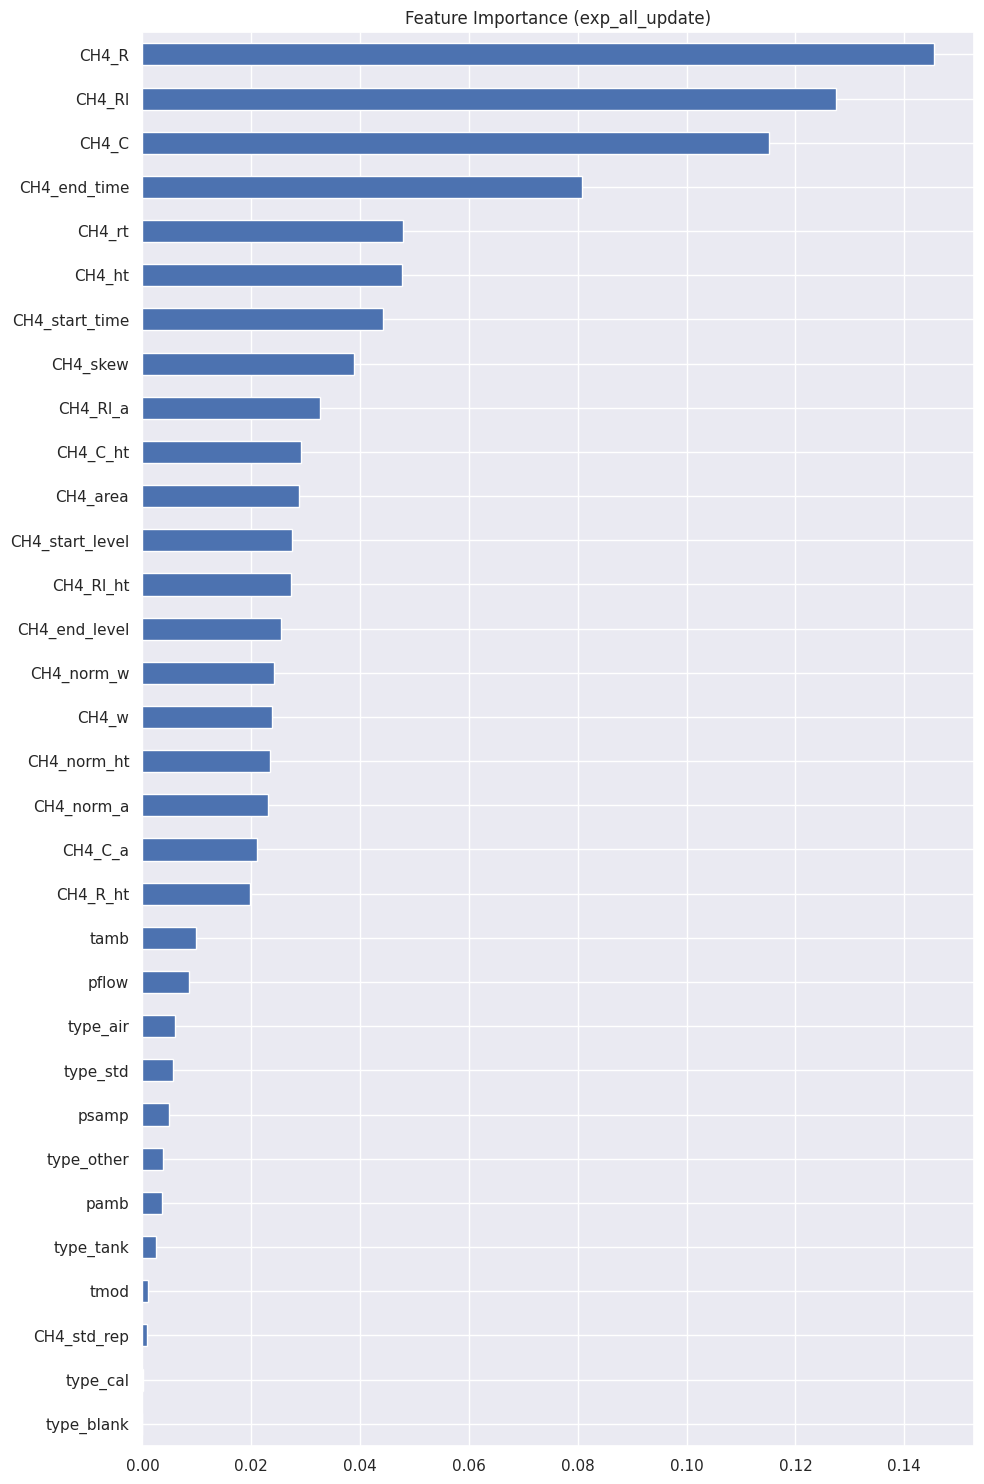

Model training...


2026/06/12 01:29:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.95      0.98      0.97    146147
           1       0.78      0.61      0.68     17444

    accuracy                           0.94    163591
   macro avg       0.87      0.79      0.83    163591
weighted avg       0.94      0.94      0.94    163591



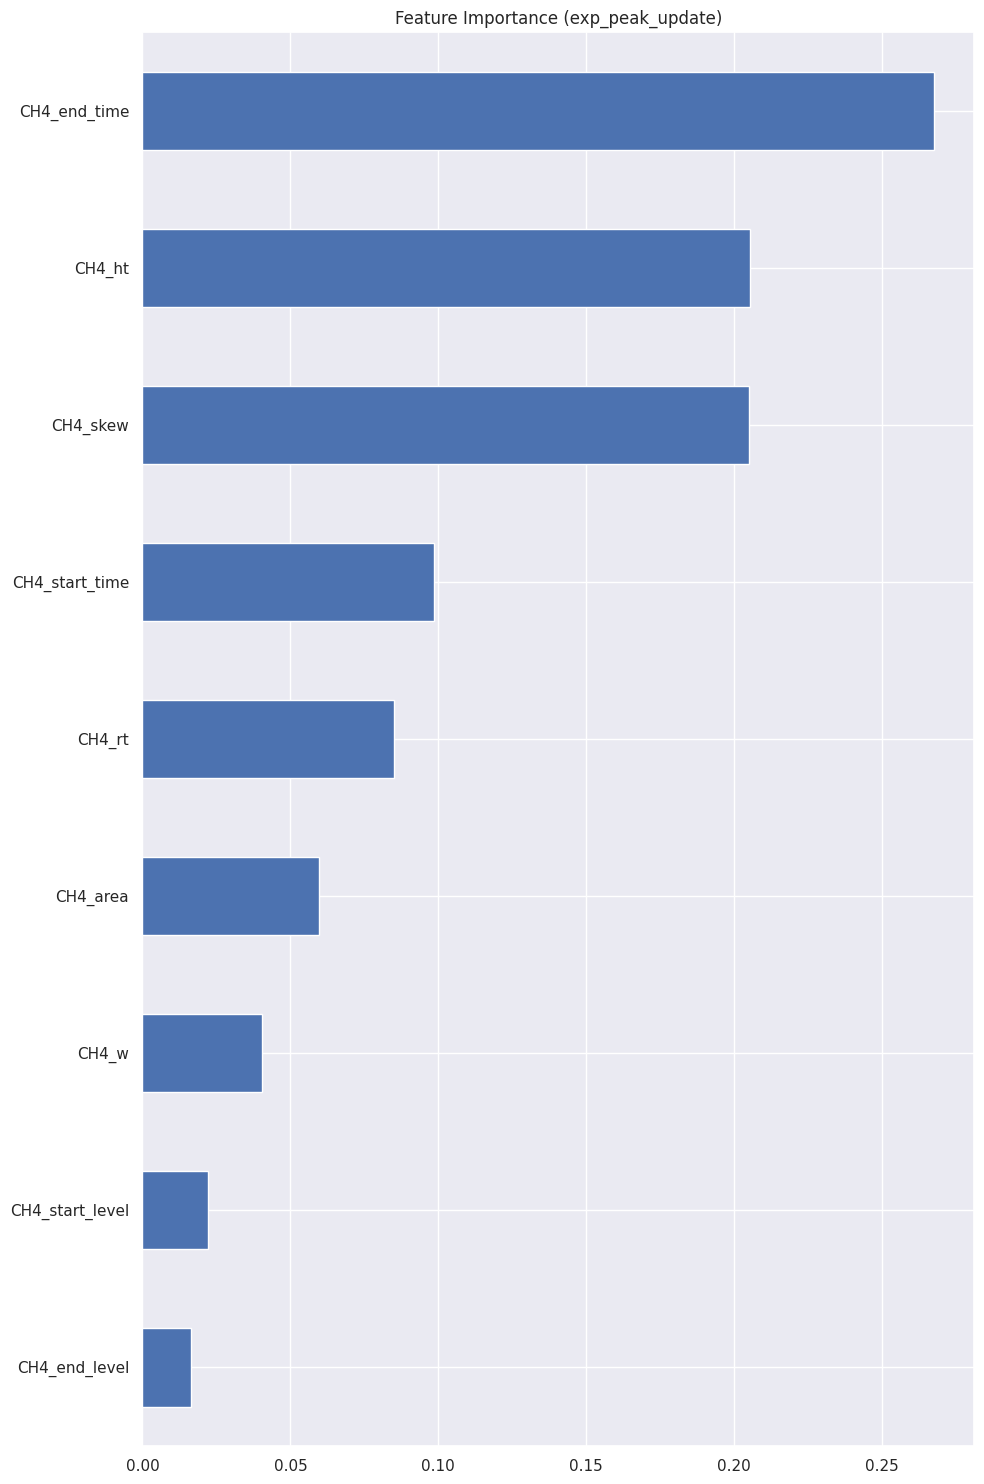

Model training...


2026/06/12 01:30:37 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/06/12 01:30:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.94      0.98      0.96    146147
           1       0.76      0.50      0.60     17444

    accuracy                           0.93    163591
   macro avg       0.85      0.74      0.78    163591
weighted avg       0.92      0.93      0.92    163591



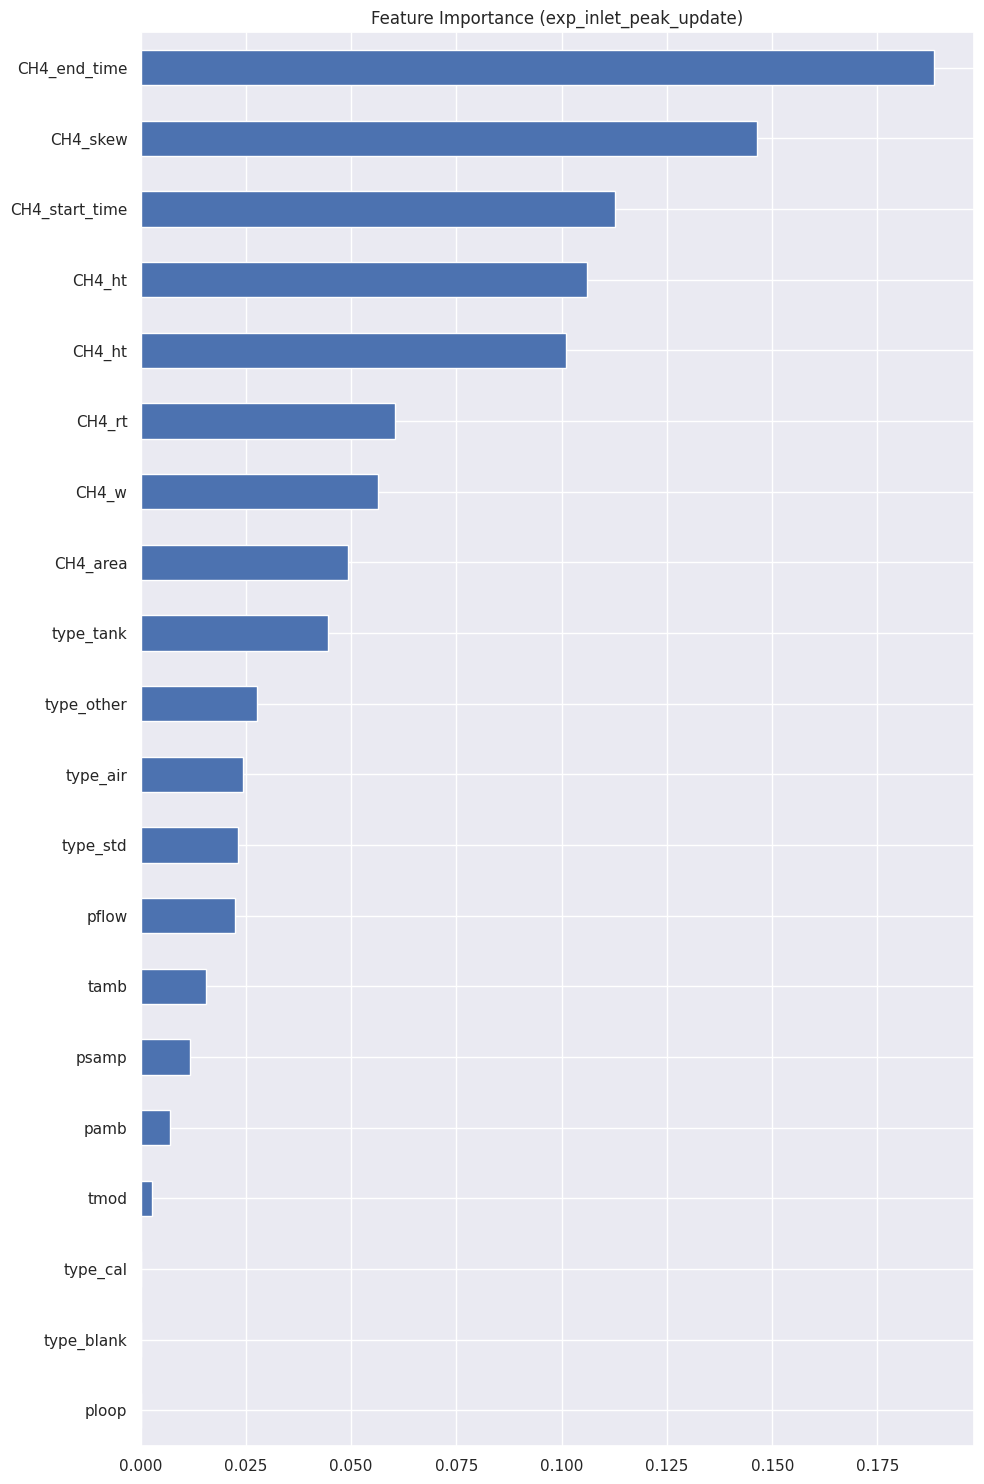

In [13]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

for f, i  in feature_experiments.items() :
    X = data[i]
    y = data['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(data)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


    mlflow.set_experiment(f"{f}_update")
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f'{f}_update',n_estimators=200, max_depth=12, n_jobs=-1
    )


CH4_Rl

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 75 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   date                    817955 non-null  int64         
 1   time                    817955 non-null  int64         
 2   type                    817954 non-null  object        
 3   sample                  817955 non-null  object        
 4   standard                817955 non-null  object        
 5   port                    817955 non-null  int64         
 6   ht                      817955 non-null  int64         
 7   tmod                    705671 non-null  float64       
 8   tamb                    705671 non-null  float64       
 9   lab_temp                0 non-null       float64       
 10  pflow                   815553 non-null  float64       
 11  psamp                   815626 non-null  float64       
 12  ploop                   0 non-

feature: columns_all performs too good
-> see how happened


In [15]:
top_features = ['CH4_Rl', 'CH4_C', 'CH4_R']

for col in top_features:
    print(f"\n=== check {col} null values condition ===")
    print(data.groupby('label1')[col].apply(lambda x: x.isna().mean()))


=== check CH4_Rl null values condition ===
label1
0    0.026260
1    0.933712
Name: CH4_Rl, dtype: float64

=== check CH4_C null values condition ===
label1
0    0.027752
1    0.933761
Name: CH4_C, dtype: float64

=== check CH4_R null values condition ===
label1
0    0.026260
1    0.933712
Name: CH4_R, dtype: float64


抓到，null值比例在label1 多達0.90

In [16]:
data_drop = data.copy()

Model training...


2026/06/12 01:30:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/12 01:31:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_pro

Model training completed!
              precision    recall  f1-score   support

           0       0.95      1.00      0.97    146147
           1       0.95      0.59      0.73     17444

    accuracy                           0.95    163591
   macro avg       0.95      0.79      0.85    163591
weighted avg       0.95      0.95      0.95    163591



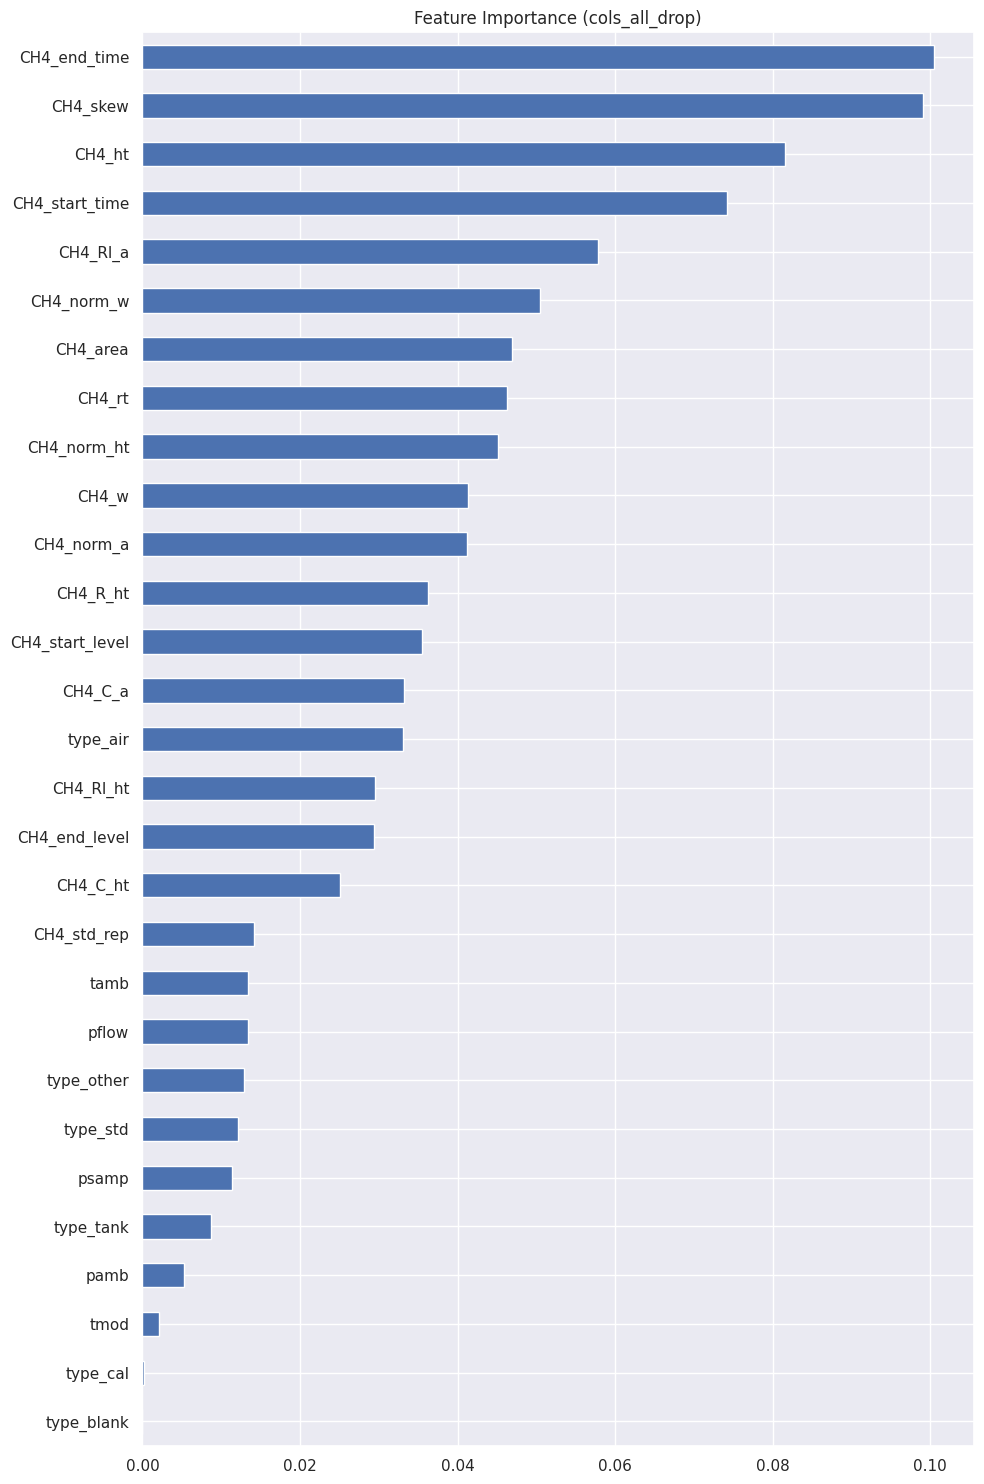

In [17]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

X = data_drop[cols_all].drop(columns=['CH4_Rl', 'CH4_C', 'CH4_R'])
y = data_drop['label1']
feature_cols = X.columns.tolist()
split_idx = int(len(data_drop)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

mlflow.set_experiment("cols_all_drop")
print("Model training...")
model = random_forest_model(
    X_train, y_train, X_test, y_test,
    feature_names=feature_cols,
    experiment_run_name='cols_all_drop',n_estimators=200, max_depth=12, n_jobs=-1
)


    shouldn'r split data randomly (should split based on the time)
    不能用隨機切分，會洩漏

In [18]:
top_features = ['CH4_Rl', 'CH4_C', 'CH4_R']

for col in top_features:
    print(f"\n=== check {col} null values condition ===")
    print(data_drop.groupby('label1')[col].apply(lambda x: x.isna().mean()))


=== check CH4_Rl null values condition ===
label1
0    0.026260
1    0.933712
Name: CH4_Rl, dtype: float64

=== check CH4_C null values condition ===
label1
0    0.027752
1    0.933761
Name: CH4_C, dtype: float64

=== check CH4_R null values condition ===
label1
0    0.026260
1    0.933712
Name: CH4_R, dtype: float64
